### **Imports**

In [1]:
import pickle, os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

def p_to_star(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return 'n.s.'

FIGSIZE = (14, 4); DPI = 600
FIGSIZE_SINGLE = (14, 4)
TICK_FONTSIZE_X_and_Y = 14; TITLE_FONTSIZE = 14; YLABEL_FONTSIZE = 14
COLORS = ["skyblue", "lightgreen", "salmon", "seashell"]


### **Main comparison figure**

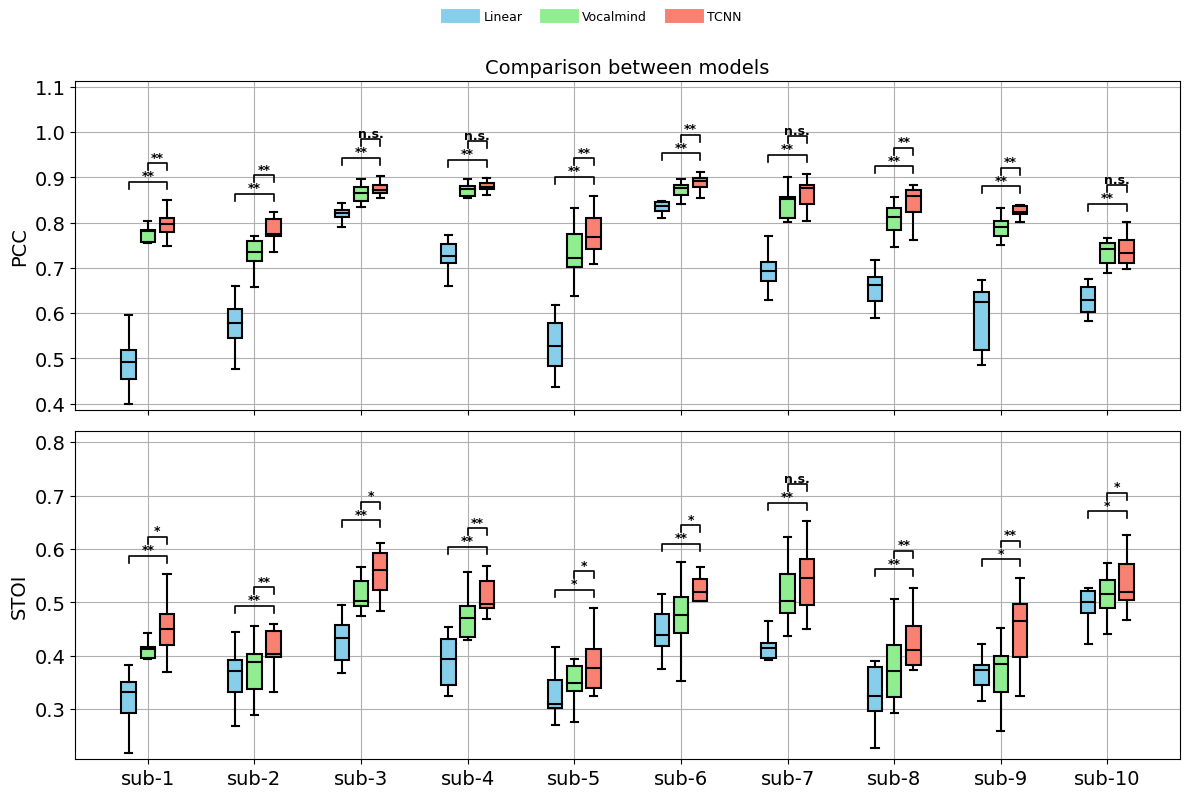

In [ ]:
# ------------------------
# Load result files
# ------------------------
files = {
    "Linear": "/home/ahmed348/TCNN_repo/pkl_files/Linear_HGA_ONLY.pkl",
    "Vocalmind": "/home/ahmed348/TCNN_repo/pkl_files/TCNN_VOCALMIND_vocalmind_7500_T_6.pkl",
    "TCNN": "/home/ahmed348/TCNN_repo/pkl_files/TCNN_HGA_LFC_355_dil_151515_ker_7500_T_6.pkl",
}
method_order = list(files.keys())

# ------------------------
# Create figure with 2 subplots (PCC and STOI)
# ------------------------
metrics = ["PCC", "STOI"]
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

for ax_idx, metric in enumerate(metrics):
    # Load data for this metric
    results = {}
    for method, fpath in files.items():
        with open(fpath, "rb") as f:
            data = pickle.load(f)
            results[method] = data[metric]  # list of n_subjects, each with 10 folds

    # ------------------------
    # Prepare boxplot data
    # ------------------------
    n_subjects = len(next(iter(results.values())))   # should be 10
    methods = list(results.keys())
    n_methods = len(methods)

    positions = []
    box_data = []
    labels = []
    width = 0.18  # spacing between methods

    for subj_idx in range(n_subjects):
        for m_idx, method in enumerate(methods):
            subj_data = results[method][subj_idx]  # list of folds for this subject
            box_data.append(subj_data)
            positions.append(subj_idx + 1 + (m_idx - (n_methods-1)/2)*width)
            labels.append(f"Subj {subj_idx+1}" if m_idx == n_methods//2 else "")

    # ------------------------
    # Plot boxplot
    # ------------------------
    ax = axes[ax_idx]
    bp = ax.boxplot(
        box_data,
        positions=positions,
        vert=True,
        widths=0.75*width,
        patch_artist=True,
        showfliers=False,
        medianprops={'color': 'black', 'linewidth': 1.5},
        whiskerprops={'linewidth': 1.5, 'color': 'black'},
        capprops={'linewidth': 1.5, 'color': 'black'},
        boxprops={'linewidth': 1.5},
    )

    # Assign colors
    for m_idx, color in enumerate(COLORS[:n_methods]):
        for patch_idx in range(m_idx, len(bp["boxes"]), n_methods):
            bp["boxes"][patch_idx].set_facecolor(color)

    # X-axis ticks at subject centers
    ax.set_xticks(range(1, n_subjects+1))
    ax.set_xticklabels([f"sub-{i+1}" for i in range(n_subjects)], rotation=0)
    ax.tick_params(axis="both", labelsize=TICK_FONTSIZE_X_and_Y)

    ax.set_ylabel(metric, fontsize=YLABEL_FONTSIZE)
    if ax_idx == 0:
        ax.set_title(f"Comparison between models", fontsize=TITLE_FONTSIZE)

    ax.grid(True)

    # Extend ylim for stars
    data_list = box_data
    all_data = np.concatenate(data_list)
    yrange = all_data.max() - all_data.min()
    ax.set_ylim(all_data.min() - yrange*0.025, all_data.max() + yrange*0.39)

    # Significance stars
    pairs = [("Linear", "TCNN"), ("Vocalmind", "TCNN")]
    m_bonf = len(pairs)
    base_offset = yrange * 0.05
    bracket_width = yrange * 0.03

    for s_idx in range(n_subjects):
        start_idx = s_idx * n_methods
        subj_positions = [positions[start_idx + m] for m in range(n_methods)]
        subj_data_arrays = [data_list[start_idx + m] for m in range(n_methods)]
        ymax = max(max(arr) for arr in subj_data_arrays)

        for level, (m1, m2) in enumerate(pairs):
            m1_idx = method_order.index(m1)
            m2_idx = method_order.index(m2)
            a, b = results[m1][s_idx], results[m2][s_idx]

            try:
                _, pval = wilcoxon(b, a, alternative='greater')
            except Exception:
                pval = 1.0
            p_adj = min(pval * m_bonf, 1.0)
            stars = p_to_star(p_adj)

            x1, x2 = subj_positions[m1_idx], subj_positions[m2_idx]
            y = ymax + base_offset + level * (base_offset + bracket_width)

            ax.plot([x1, x1, x2, x2],
                    [y, y+bracket_width, y+bracket_width, y],
                    lw=1.2, c='black')
            ax.text((x1+x2)/2, y+bracket_width*0.9, stars,
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.95])  # leave space at top for legend
fig.legend(
    handles=[plt.Line2D([], [], color=COLORS[i], linewidth=10, label=method) for i, method in enumerate(methods)],
    loc='upper center',
    ncol=len(methods),
    frameon=False,
    fontsize=9
)
plt.savefig('/home/ahmed348/TCNN_repo/figures/main_comparison_figure.pdf', bbox_inches='tight', dpi=DPI)
plt.show()


### **Effect of receptive field size (lineplot)**

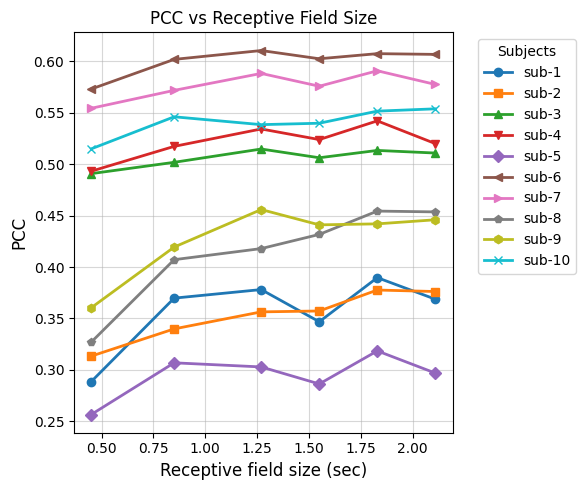

In [3]:
## show a curve where you reach saturation ultimately 
import pickle
import numpy as np
import matplotlib.pyplot as plt

# ------------------------
# User inputs
# ------------------------
metric = "PCC"  # or "STOI"

# files = [
#     "/home/ahmed348/TCNN_repo/pkl_files/TCNN_HGA_LFC_111_dil_151515_ker_7500_T_6.pkl",
#     "/home/ahmed348/TCNN_repo/pkl_files/TCNN_HGA_LFC_123_dil_151515_ker_7500_T_6.pkl",
#     "/home/ahmed348/TCNN_repo/pkl_files/TCNN_HGA_LFC_135_dil_151515_ker_7500_T_6.pkl",
#     "/home/ahmed348/TCNN_repo/pkl_files/TCNN_HGA_LFC_335_dil_151515_ker_7500_T_6.pkl",
#     "/home/ahmed348/TCNN_repo/pkl_files/TCNN_HGA_LFC_355_dil_151515_ker_7500_T_6.pkl",
#     "/home/ahmed348/TCNN_repo/pkl_files/TCNN_HGA_LFC_357_dil_151515_ker_7500_T_6.pkl"
# ]
files = [
    "/home/ahmed348/TCNN_repo/pkl_files/TCNN_HGA_LFC_111_dil_151515_ker_7500_T_6_speech_only.pkl",
    "/home/ahmed348/TCNN_repo/pkl_files/TCNN_HGA_LFC_123_dil_151515_ker_7500_T_6_speech_only.pkl",
    "/home/ahmed348/TCNN_repo/pkl_files/TCNN_HGA_LFC_135_dil_151515_ker_7500_T_6_speech_only.pkl",
    "/home/ahmed348/TCNN_repo/pkl_files/TCNN_HGA_LFC_335_dil_151515_ker_7500_T_6_speech_only.pkl",
    "/home/ahmed348/TCNN_repo/pkl_files/TCNN_HGA_LFC_355_dil_151515_ker_7500_T_6_speech_only.pkl",
    "/home/ahmed348/TCNN_repo/pkl_files/TCNN_HGA_LFC_357_dil_151515_ker_7500_T_6_speech_only.pkl"
]
# Parameter values corresponding to each file
param_values = [45, 85, 127, 155, 183, 211]   # must have len=7
param_values = [param_values[i]/100 for i in range(len(param_values))]

# ------------------------
# Load files & collect averages
# ------------------------
all_subject_avgs = []   # will be shape [7 files, 10 subjects]

for fpath in files:
    with open(fpath, "rb") as f:
        data = pickle.load(f)

    # data[metric] → list of length 10 subjects
    # each subject entry is a list of 10 folds
    subject_lists = data[metric]

    # average across folds → 10 averaged values
    subject_means = [np.mean(folds) for folds in subject_lists]
    all_subject_avgs.append(subject_means)

all_subject_avgs = np.array(all_subject_avgs)   # shape = (7, 10)

# ------------------------
# Plot
# ------------------------
markers = ['o', 's', '^', 'v', 'D', '<', '>', 'p', 'h', 'x']
fig, ax = plt.subplots(figsize=(6, 5))

n_subjects = all_subject_avgs.shape[1]
for subj_idx in range(n_subjects):
    ax.plot(
        param_values,
        all_subject_avgs[:, subj_idx],
        # marker='o',
        marker=markers[subj_idx % len(markers)],
        linewidth=2,
        label=f"sub-{subj_idx+1}"
    )

ax.set_xlabel("Receptive field size (sec)", fontsize=12)
ax.set_ylabel(metric, fontsize=12)
ax.set_title(f"{metric} vs Receptive Field Size", fontsize=12)
ax.grid(True, alpha=0.5)

# trial_x = 3
# ax.axvline(trial_x, linestyle='--', color='gray')

# # ---- Clean in-figure label (use data coords, not axis coords) ----
# ax.text(trial_x, ax.get_ylim()[0] + 0.05*(ax.get_ylim()[1]-ax.get_ylim()[0]),
#         "trial length",
#         ha='center', va='bottom',
#         fontsize=8, #fontweight='bold',
#         bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.8)
# )

# min_x = min(param_values)
# max_x = max(param_values)
# ax.set_xticks(np.arange(0.05 * (min_x//50), max_x + 51, 50))

# Optional: place legend outside
ax.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    title="Subjects"
)

plt.tight_layout()
plt.savefig('/home/ahmed348/TCNN_repo/figures/effect_of_receptive_field.pdf', bbox_inches='tight', dpi=DPI)
# plt.show()


### **Effect of receptive field size (three in one: PCC, PCC-speech_only, STOI**)

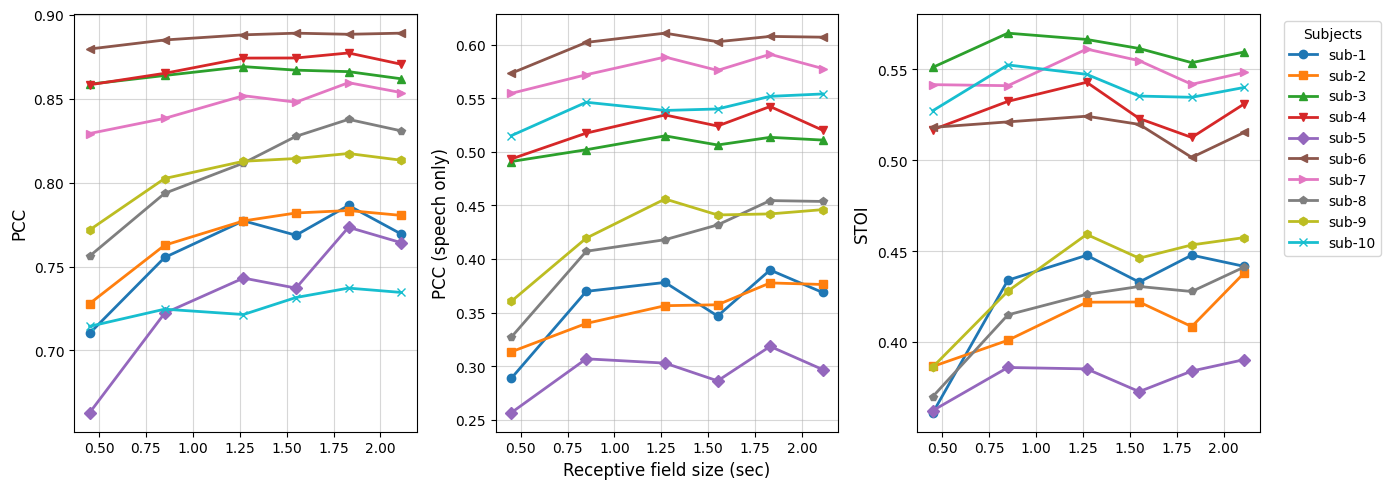

In [7]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

# ------------------------
# File sets (hard-coded)
# ------------------------
files_set1 = [
    "/home/ahmed348/TCNN_repo/pkl_files/TCNN_HGA_LFC_111_dil_151515_ker_7500_T_6.pkl",
    "/home/ahmed348/TCNN_repo/pkl_files/TCNN_HGA_LFC_123_dil_151515_ker_7500_T_6.pkl",
    "/home/ahmed348/TCNN_repo/pkl_files/TCNN_HGA_LFC_135_dil_151515_ker_7500_T_6.pkl",
    "/home/ahmed348/TCNN_repo/pkl_files/TCNN_HGA_LFC_335_dil_151515_ker_7500_T_6.pkl",
    "/home/ahmed348/TCNN_repo/pkl_files/TCNN_HGA_LFC_355_dil_151515_ker_7500_T_6.pkl",
    "/home/ahmed348/TCNN_repo/pkl_files/TCNN_HGA_LFC_357_dil_151515_ker_7500_T_6.pkl",
]
files_set2 = [
    "/home/ahmed348/TCNN_repo/pkl_files/TCNN_HGA_LFC_111_dil_151515_ker_7500_T_6_speech_only.pkl",
    "/home/ahmed348/TCNN_repo/pkl_files/TCNN_HGA_LFC_123_dil_151515_ker_7500_T_6_speech_only.pkl",
    "/home/ahmed348/TCNN_repo/pkl_files/TCNN_HGA_LFC_135_dil_151515_ker_7500_T_6_speech_only.pkl",
    "/home/ahmed348/TCNN_repo/pkl_files/TCNN_HGA_LFC_335_dil_151515_ker_7500_T_6_speech_only.pkl",
    "/home/ahmed348/TCNN_repo/pkl_files/TCNN_HGA_LFC_355_dil_151515_ker_7500_T_6_speech_only.pkl",
    "/home/ahmed348/TCNN_repo/pkl_files/TCNN_HGA_LFC_357_dil_151515_ker_7500_T_6_speech_only.pkl",
]

# ------------------------
# Parameters
# ------------------------
param_values = [45, 85, 127, 155, 183, 211]
param_values = [p / 100 for p in param_values]

markers = ['o', 's', '^', 'v', 'D', '<', '>', 'p', 'h', 'x']

# ------------------------
# Helper
# ------------------------
def load_subject_means(files, metric):
    all_subject_avgs = []
    for fpath in files:
        with open(fpath, "rb") as f:
            data = pickle.load(f)
        subject_means = [np.mean(folds) for folds in data[metric]]
        all_subject_avgs.append(subject_means)
    return np.array(all_subject_avgs)

# ------------------------
# Load data
# ------------------------
pcc_set1 = load_subject_means(files_set1, "PCC")
pcc_set2 = load_subject_means(files_set2, "PCC")
stoi_set1 = load_subject_means(files_set1, "STOI")

# ------------------------
# Plot: 1 × 3 layout
# ------------------------
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharex=True)

plot_specs = [
    (axes[0], pcc_set1, "PCC"),
    (axes[1], pcc_set2, "PCC (speech only)"),
    (axes[2], stoi_set1, "STOI"),
]

for ax, data, ylabel in plot_specs:
    n_subjects = data.shape[1]
    for subj_idx in range(n_subjects):
        ax.plot(
            param_values,
            data[:, subj_idx],
            marker=markers[subj_idx % len(markers)],
            linewidth=2,
            label=f"sub-{subj_idx+1}"
        )

    ax.set_ylabel(ylabel, fontsize=12)
    ax.grid(True, alpha=0.5)

# X-axis label only once (middle looks cleanest in papers)
# axes[0].set_xlabel("Receptive field size (sec)", fontsize=12)
axes[1].set_xlabel("Receptive field size (sec)", fontsize=12)
# axes[2].set_xlabel("Receptive field size (sec)", fontsize=12)

# ------------------------
# Legend only on far right
# ------------------------
axes[2].legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    title="Subjects"
)

plt.tight_layout()
plt.savefig(
    "/home/ahmed348/TCNN_repo/figures/effect_of_receptive_field_3panel_row.pdf",
    bbox_inches="tight",
    dpi=DPI,
)
# plt.show()


### **Effect of Dilations**

['no_dil', 'rf1', 'rf2']


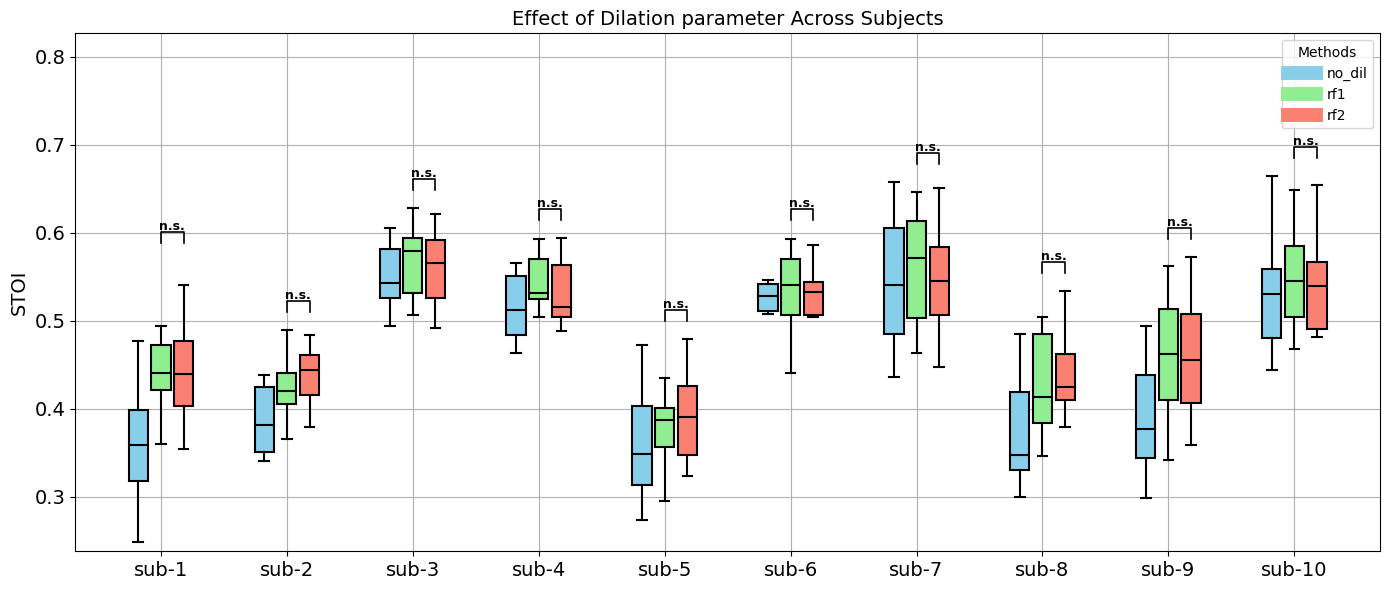

In [8]:
import pickle
import matplotlib.pyplot as plt
import numpy as np

# ------------------------
# Choose metric
# ------------------------
metric = "STOI"   # change to "STOI" or "PCC" if needed

# ------------------------
# Load result files
# ------------------------
files = {
    "no_dil": "/home/ahmed348/TCNN_repo/pkl_files/TCNN_HGA_LFC_111_dil_151515_ker_7500_T_6.pkl",
    "rf1": "/home/ahmed348/TCNN_repo/pkl_files/TCNN_HGA_LFC_135_dil_151515_ker_7500_T_6.pkl",
    "rf2": "/home/ahmed348/TCNN_repo/pkl_files/TCNN_HGA_LFC_357_dil_151515_ker_7500_T_6.pkl",
    # "rf3": "/home/ahmed348/TCNN_repo/pkl_files/TCNN_HGA_LFC_357_dil_151515_ker_7500_T_6.pkl",
}
method_order =  list(files.keys())
print(method_order)
results = {}
for method, fpath in files.items():
    with open(fpath, "rb") as f:
        data = pickle.load(f)
        results[method] = data[metric]  # list of n_subjects, each with 10 folds

# ------------------------
# Prepare boxplot data
# ------------------------
n_subjects = len(next(iter(results.values())))   # should be 10
methods = list(results.keys())
n_methods = len(methods)

positions = []
box_data = []
labels = []

width = 0.18  # spacing between methods
for subj_idx in range(n_subjects):
    for m_idx, method in enumerate(methods):
        subj_data = results[method][subj_idx]  # list of folds for this subject
        box_data.append(subj_data)
        # center around subject index
        positions.append(subj_idx + 1 + (m_idx - (n_methods-1)/2)*width)
        labels.append(f"Subj {subj_idx+1}" if m_idx == n_methods//2 else "")

# ------------------------
# Plot
# ------------------------
fig, ax = plt.subplots(figsize=(14, 6))

# Boxplot
bp = ax.boxplot(
    box_data,
    positions=positions,
    vert=True,
    widths=0.85*width,
    patch_artist=True,
    showfliers=False,
    medianprops={'color': 'black', 'linewidth': 1.5},
    whiskerprops={'linewidth': 1.5, 'color': 'black'},
    capprops={'linewidth': 1.5, 'color': 'black'},
    boxprops={'linewidth': 1.5},
)

# Assign colors (extendable if more methods are added)
colors = COLORS 
for m_idx, color in enumerate(colors[:n_methods]):
    for patch_idx in range(m_idx, len(bp["boxes"]), n_methods):
        bp["boxes"][patch_idx].set_facecolor(color)

# X-axis ticks at subject centers
ax.set_xticks(range(1, n_subjects+1))
ax.set_xticklabels([f"sub-{i+1}" for i in range(n_subjects)], rotation=0)
ax.tick_params(axis="both", labelsize=TICK_FONTSIZE_X_and_Y)

ax.set_ylabel(metric, fontsize=YLABEL_FONTSIZE)
ax.set_title(f"Effect of Dilation parameter Across Subjects", fontsize=TITLE_FONTSIZE)

# Legend
for m_idx, method in enumerate(methods):
    ax.plot([], c=colors[m_idx], label=method, linewidth=10)
ax.legend(title="Methods")

# Extend ylim for stars
data_list = box_data
all_data = np.concatenate(data_list)
yrange = all_data.max() - all_data.min()
ax.set_ylim(all_data.min() - yrange*0.025, all_data.max() + yrange*0.39)
ax.grid(True) 

# Significance stars
# pairs = [("no_dil", "rf1"), ("rf1","rf2"), ("rf2", "rf3")] ## (a, b) -- b is better than a : H_a
pairs = [("rf1", "rf2")]
m_bonf = len(pairs)

base_offset = yrange * 0.05
bracket_width = yrange * 0.03 # 0.03

for s_idx in range(n_subjects):
    start_idx = s_idx * n_methods
    subj_positions = [positions[start_idx + m] for m in range(n_methods)]
    subj_data_arrays = [data_list[start_idx + m] for m in range(n_methods)]
    ymax = max(max(arr) for arr in subj_data_arrays)

    for level, (m1, m2) in enumerate(pairs):
        m1_idx = method_order.index(m1)
        m2_idx = method_order.index(m2)
        # a, b = subj_data_arrays[m1_idx], subj_data_arrays[m2_idx]
        a, b = results[m1][s_idx], results[m2][s_idx]

        try:
            _, pval = wilcoxon(b, a, alternative='two-sided')
        except Exception:
            pval = 1.0
        p_adj = min(pval * m_bonf, 1.0)
        stars = p_to_star(p_adj)

        x1, x2 = subj_positions[m1_idx], subj_positions[m2_idx]
        y = ymax + base_offset + level * (base_offset + bracket_width)

        ax.plot([x1, x1, x2, x2],
                [y, y+bracket_width, y+bracket_width, y],
                lw=1.2, c='black')
        ax.text((x1+x2)/2, y+bracket_width*0.9, stars,
                ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('/home/ahmed348/TCNN_repo/figures/effect_of_dilations.pdf', bbox_inches='tight', dpi=DPI)
plt.show() 


### **Effect of using LFC-HGA**

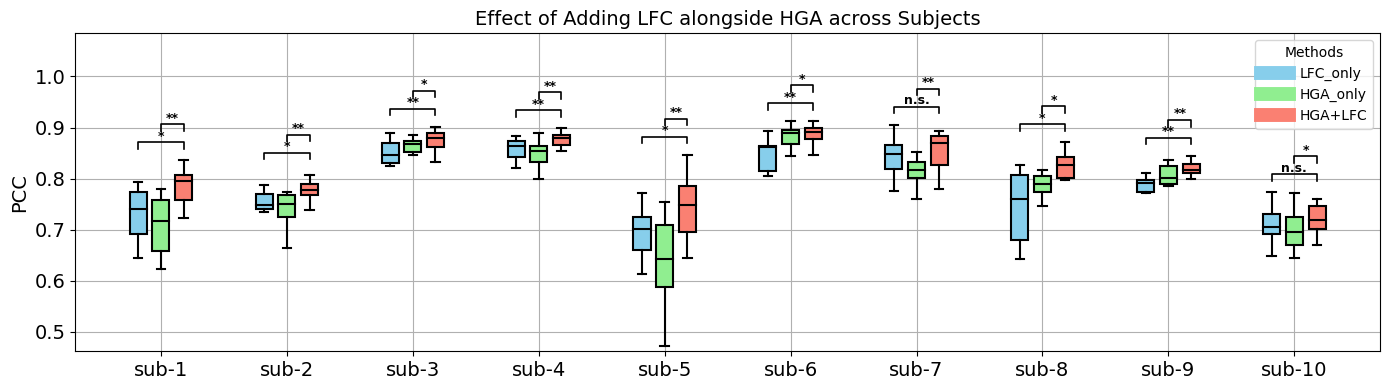

In [10]:
# ------------------------
# Choose metric 
# ------------------------
metric = "PCC"   # change to "STOI" or "PCC" if needed

# ------------------------
# Load result files
# ------------------------
files = {
    "LFC_only": "/home/ahmed348/TCNN_repo/pkl_files/TCNN_LFC_ONLY_135_dil_151515_ker_7500_T_6.pkl",
    "HGA_only": "/home/ahmed348/TCNN_repo/pkl_files/TCNN_HGA_ONLY_135_dil_151515_ker_7500_T_6.pkl",
    "HGA+LFC": "/home/ahmed348/TCNN_repo/pkl_files/TCNN_HGA_LFC_135_dil_151515_ker_7500_T_6.pkl",
}
method_order =  list(files.keys())
results = {}
for method, fpath in files.items():
    with open(fpath, "rb") as f:
        data = pickle.load(f)
        results[method] = data[metric]  # list of n_subjects, each with 10 folds

# ------------------------
# Prepare boxplot data
# ------------------------
n_subjects = len(next(iter(results.values())))   # should be 10
methods = list(results.keys())
n_methods = len(methods)

positions = []
box_data = []
labels = []

width = 0.18  # spacing between methods
for subj_idx in range(n_subjects):
    for m_idx, method in enumerate(methods):
        subj_data = results[method][subj_idx]  # list of folds for this subject
        box_data.append(subj_data)
        # center around subject index
        positions.append(subj_idx + 1 + (m_idx - (n_methods-1)/2)*width)
        labels.append(f"Subj {subj_idx+1}" if m_idx == n_methods//2 else "")

# ------------------------
# Plot
# ------------------------
fig, ax = plt.subplots(figsize=FIGSIZE)
bp = ax.boxplot(
    box_data,
    positions=positions,
    vert=True,
    widths=0.75*width,
    patch_artist=True,
    showfliers=False,
    medianprops={'color': 'black', 'linewidth': 1.5},
    whiskerprops={'linewidth': 1.5, 'color': 'black'},
    capprops={'linewidth': 1.5, 'color': 'black'},
    boxprops={'linewidth': 1.5},
)

# Assign colors (extendable if more methods are added)
colors = COLORS 
# colors = ["skyblue", "lightgreen", "salmon", "plum"]
for m_idx, color in enumerate(colors[:n_methods]):
    for patch_idx in range(m_idx, len(bp["boxes"]), n_methods):
        bp["boxes"][patch_idx].set_facecolor(color)

# X-axis ticks at subject centers
ax.set_xticks(range(1, n_subjects+1))
ax.set_xticklabels([f"sub-{i+1}" for i in range(n_subjects)], rotation=0)
ax.tick_params(axis="both", labelsize=TICK_FONTSIZE_X_and_Y)

ax.set_ylabel(metric, fontsize=YLABEL_FONTSIZE)
ax.set_title(f"Effect of Adding LFC alongside HGA across Subjects", fontsize=TITLE_FONTSIZE)

# Legend
for m_idx, method in enumerate(methods):
    ax.plot([], c=colors[m_idx], label=method, linewidth=10)
ax.legend(title="Methods")
ax.grid(True) 

# Extend ylim for stars
data_list = box_data
all_data = np.concatenate(data_list)
yrange = all_data.max() - all_data.min()
ax.set_ylim(all_data.min() - yrange*0.025, all_data.max() + yrange*0.39)
ax.grid(True) 

# Significance stars
pairs = [("LFC_only", "HGA+LFC"), ("HGA_only", "HGA+LFC")]
m_bonf = len(pairs)

base_offset = yrange * 0.05
bracket_width = yrange * 0.03 # 0.03

for s_idx in range(n_subjects):
    start_idx = s_idx * n_methods
    subj_positions = [positions[start_idx + m] for m in range(n_methods)]
    subj_data_arrays = [data_list[start_idx + m] for m in range(n_methods)]
    ymax = max(max(arr) for arr in subj_data_arrays)

    for level, (m1, m2) in enumerate(pairs):
        m1_idx = method_order.index(m1)
        m2_idx = method_order.index(m2)
        # a, b = subj_data_arrays[m1_idx], subj_data_arrays[m2_idx]
        a, b = results[m1][s_idx], results[m2][s_idx]

        try:
            _, pval = wilcoxon(b, a, alternative = 'greater')
        except Exception:
            pval = 1.0
        p_adj = min(pval * m_bonf, 1.0)
        stars = p_to_star(p_adj)

        x1, x2 = subj_positions[m1_idx], subj_positions[m2_idx]
        y = ymax + base_offset + level * (base_offset + bracket_width)

        ax.plot([x1, x1, x2, x2],
                [y, y+bracket_width, y+bracket_width, y],
                lw=1.2, c='black')
        ax.text((x1+x2)/2, y+bracket_width*0.9, stars,
                ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('/home/ahmed348/TCNN_repo/figures/effect_of_adding_LFC_and_HGA.pdf', bbox_inches='tight', dpi=DPI)
plt.show() 


### **Effect of using different fc for LFC**

### **Effect of using PCA features instead of true sEEG**

In [1]:
# ------------------------
# Choose metric
# ------------------------
metric = "PCC"   # change to "STOI" or "PCC" if needed

# ------------------------
# Load result files
# ------------------------
files = {
    "with_pca": "/home/ahmed348/TCNN_repo/pkl_files/TCNN_HGA_LFC_135_dil_151515_ker_7500_T_6_pca.pkl",
    # "silence_only": "/home/ahmed348/TCNN_repo/pkl_files/TCNN_HGA_LFC_579_dil_151515_ker_7500_T_6_sil_only.pkl", 
    "orig_channels": "/home/ahmed348/TCNN_repo/pkl_files/TCNN_HGA_LFC_135_dil_151515_ker_7500_T_6.pkl",
}
method_order =  list(files.keys())
results = {}
for method, fpath in files.items():
    with open(fpath, "rb") as f:
        data = pickle.load(f)
        results[method] = data[metric]  # list of n_subjects, each with 10 folds

# ------------------------
# Prepare boxplot data
# ------------------------
n_subjects = len(next(iter(results.values())))   # should be 10
methods = list(results.keys())
n_methods = len(methods)

positions = []
box_data = []
labels = []

width = 0.18  # spacing between methods
for subj_idx in range(n_subjects):
    for m_idx, method in enumerate(methods):
        subj_data = results[method][subj_idx]  # list of folds for this subject
        box_data.append(subj_data)
        # center around subject index
        positions.append(subj_idx + 1 + (m_idx - (n_methods-1)/2)*width)
        labels.append(f"Subj {subj_idx+1}" if m_idx == n_methods//2 else "")

# ------------------------
# Plot
# ------------------------
fig, ax = plt.subplots(figsize=FIGSIZE)
bp = ax.boxplot(
    box_data,
    positions=positions,
    vert=True,
    widths=0.75*width,
    patch_artist=True,
    showfliers=False,
    medianprops={'color': 'black', 'linewidth': 1.5},
    whiskerprops={'linewidth': 1.5, 'color': 'black'},
    capprops={'linewidth': 1.5, 'color': 'black'},
    boxprops={'linewidth': 1.5},
)

# Assign colors (extendable if more methods are added)
colors = COLORS 
# colors = ["skyblue", "lightgreen", "salmon", "plum"]
for m_idx, color in enumerate(colors[:n_methods]):
    for patch_idx in range(m_idx, len(bp["boxes"]), n_methods):
        bp["boxes"][patch_idx].set_facecolor(color)

# X-axis ticks at subject centers
ax.set_xticks(range(1, n_subjects+1))
ax.set_xticklabels([f"sub-{i+1}" for i in range(n_subjects)], rotation=0)
ax.tick_params(axis="both", labelsize=TICK_FONTSIZE_X_and_Y)

ax.set_ylabel(metric, fontsize=YLABEL_FONTSIZE)
ax.set_title(f"Effect of using PCA reduced channels across Subjects", fontsize=TITLE_FONTSIZE)

# Legend
for m_idx, method in enumerate(methods):
    ax.plot([], c=colors[m_idx], label=method, linewidth=10)
ax.legend(title="Methods")
ax.grid(True) 

# Extend ylim for stars
data_list = box_data
all_data = np.concatenate(data_list)
yrange = all_data.max() - all_data.min()
ax.set_ylim(all_data.min() - yrange*0.025, all_data.max() + yrange*0.39)
ax.grid(True) 

# Significance stars
pairs = [("with_pca", "orig_channels")]
m_bonf = len(pairs)

base_offset = yrange * 0.05
bracket_width = yrange * 0.03 # 0.03

for s_idx in range(n_subjects):
    start_idx = s_idx * n_methods
    subj_positions = [positions[start_idx + m] for m in range(n_methods)]
    subj_data_arrays = [data_list[start_idx + m] for m in range(n_methods)]
    ymax = max(max(arr) for arr in subj_data_arrays)

    for level, (m1, m2) in enumerate(pairs):
        m1_idx = method_order.index(m1)
        m2_idx = method_order.index(m2)
        # a, b = subj_data_arrays[m1_idx], subj_data_arrays[m2_idx]
        a, b = results[m1][s_idx], results[m2][s_idx]

        try:
            _, pval = wilcoxon(b, a, alternative = 'two-sided')
        except Exception:
            pval = 1.0
        p_adj = min(pval * m_bonf, 1.0)
        stars = p_to_star(p_adj)

        x1, x2 = subj_positions[m1_idx], subj_positions[m2_idx]
        y = ymax + base_offset + level * (base_offset + bracket_width)

        ax.plot([x1, x1, x2, x2],
                [y, y+bracket_width, y+bracket_width, y],
                lw=1.2, c='black')
        ax.text((x1+x2)/2, y+bracket_width*0.9, stars,
                ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('/home/ahmed348/TCNN_repo/pkl_files/effect_of_pca.pdf', bbox_inches='tight', dpi=DPI)
plt.show() 


NameError: name 'pickle' is not defined

### **Effect of causal/anti-causal/non-causal convolutions in TCNN**

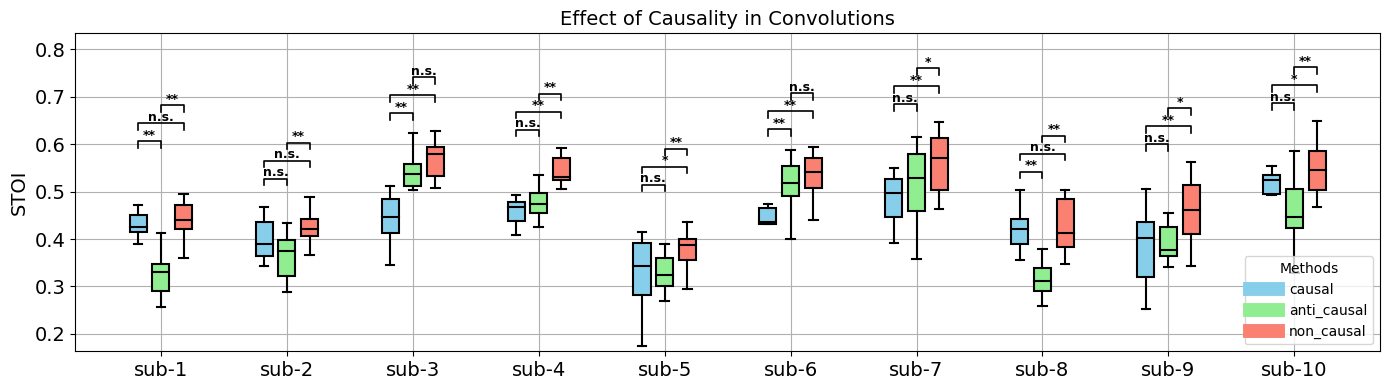

In [7]:
# ------------------------
# Choose metric 
# ------------------------
metric = "STOI"   # change to "STOI" or "PCC" if needed

# ------------------------
# Load result files
# ------------------------
files = {
    "causal": "/home/ahmed348/TCNN_repo/pkl_files/TCNN_HGA_LFC_135_dil_151515_ker_7500_T_6_causal.pkl",
    "anti_causal": "/home/ahmed348/TCNN_repo/pkl_files/TCNN_HGA_LFC_135_dil_151515_ker_7500_T_6_anti_causal.pkl",
    "non_causal": "/home/ahmed348/TCNN_repo/pkl_files/TCNN_HGA_LFC_135_dil_151515_ker_7500_T_6.pkl",
}
method_order =  list(files.keys())
results = {}
for method, fpath in files.items():
    with open(fpath, "rb") as f:
        data = pickle.load(f)
        results[method] = data[metric]  # list of n_subjects, each with 10 folds

# ------------------------
# Prepare boxplot data
# ------------------------
n_subjects = len(next(iter(results.values())))   # should be 10
methods = list(results.keys())
n_methods = len(methods)

positions = []
box_data = []
labels = []

width = 0.18  # spacing between methods
for subj_idx in range(n_subjects):
    for m_idx, method in enumerate(methods):
        subj_data = results[method][subj_idx]  # list of folds for this subject
        box_data.append(subj_data)
        # center around subject index
        positions.append(subj_idx + 1 + (m_idx - (n_methods-1)/2)*width)
        labels.append(f"Subj {subj_idx+1}" if m_idx == n_methods//2 else "")

# ------------------------
# Plot
# ------------------------
fig, ax = plt.subplots(figsize=FIGSIZE_SINGLE)
bp = ax.boxplot(
    box_data,
    positions=positions,
    vert=True,
    widths=0.75*width,
    patch_artist=True,
    showfliers=False,
    medianprops={'color': 'black', 'linewidth': 1.5},
    whiskerprops={'linewidth': 1.5, 'color': 'black'},
    capprops={'linewidth': 1.5, 'color': 'black'},
    boxprops={'linewidth': 1.5},
)

# Assign colors (extendable if more methods are added)
colors = COLORS 
# colors = ["skyblue", "lightgreen", "salmon", "plum"]
for m_idx, color in enumerate(colors[:n_methods]):
    for patch_idx in range(m_idx, len(bp["boxes"]), n_methods):
        bp["boxes"][patch_idx].set_facecolor(color)

# X-axis ticks at subject centers
ax.set_xticks(range(1, n_subjects+1))
ax.set_xticklabels([f"sub-{i+1}" for i in range(n_subjects)], rotation=0)
ax.tick_params(axis="both", labelsize=TICK_FONTSIZE_X_and_Y)

ax.set_ylabel(metric, fontsize=YLABEL_FONTSIZE)
ax.set_title(f"Effect of Causality in Convolutions", fontsize=TITLE_FONTSIZE)

# Legend
for m_idx, method in enumerate(methods):
    ax.plot([], c=colors[m_idx], label=method, linewidth=10)
ax.legend(title="Methods")
ax.grid(True) 

# Extend ylim for stars
data_list = box_data
all_data = np.concatenate(data_list)
yrange = all_data.max() - all_data.min()
ax.set_ylim(all_data.min() - yrange*0.025, all_data.max() + yrange*0.39)
ax.grid(True) 

# Significance stars
pairs = [("causal", "anti_causal"), ("causal", "non_causal"), ("anti_causal", "non_causal")]
m_bonf = len(pairs)

base_offset = yrange * 0.05
bracket_width = yrange * 0.03 # 0.03

for s_idx in range(n_subjects):
    start_idx = s_idx * n_methods
    subj_positions = [positions[start_idx + m] for m in range(n_methods)]
    subj_data_arrays = [data_list[start_idx + m] for m in range(n_methods)]
    ymax = max(max(arr) for arr in subj_data_arrays)

    for level, (m1, m2) in enumerate(pairs):
        m1_idx = method_order.index(m1)
        m2_idx = method_order.index(m2)
        # a, b = subj_data_arrays[m1_idx], subj_data_arrays[m2_idx]
        a, b = results[m1][s_idx], results[m2][s_idx]

        try:
            _, pval = wilcoxon(b, a, alternative = 'two-sided')
        except Exception:
            pval = 1.0
        p_adj = min(pval * m_bonf, 1.0)
        stars = p_to_star(p_adj)

        x1, x2 = subj_positions[m1_idx], subj_positions[m2_idx]
        y = ymax + base_offset + level * (base_offset + bracket_width)

        ax.plot([x1, x1, x2, x2],
                [y, y+bracket_width, y+bracket_width, y],
                lw=1.2, c='black')
        ax.text((x1+x2)/2, y+bracket_width*0.9, stars,
                ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('/home/ahmed348/TCNN_repo/figures/effect_of_causality.pdf', bbox_inches='tight', dpi=DPI)
plt.show() 


### **Effect of speech only evaluation**

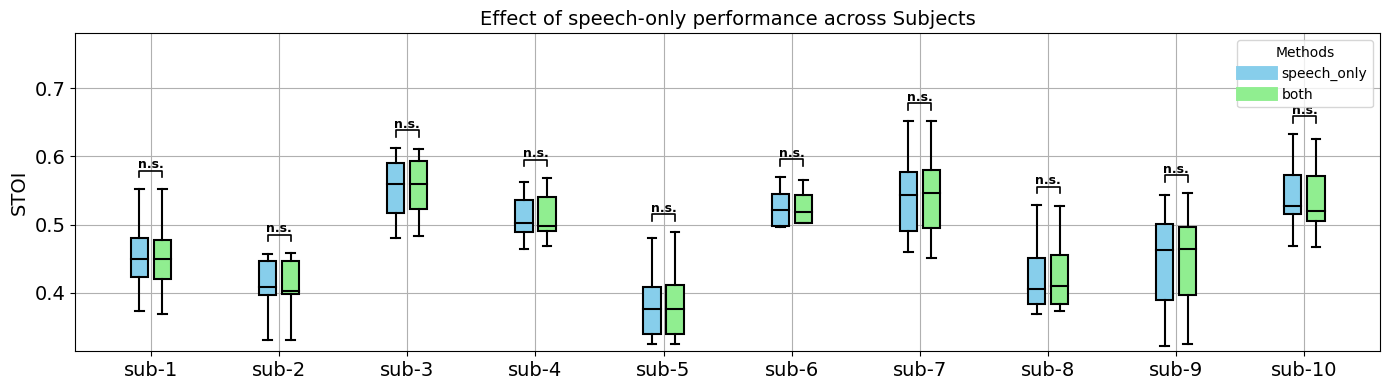

In [13]:
# ------------------------
# Choose metric
# ------------------------
metric = "STOI"   # change to "STOI" or "PCC" if needed

# ------------------------
# Load result files
# ------------------------
files = {
    "speech_only": "/home/ahmed348/TCNN_repo/pkl_files/TCNN_HGA_LFC_355_dil_151515_ker_7500_T_6_speech_only.pkl",
    # "silence_only": "/home/ahmed348/TCNN_repo/pkl_files/TCNN_HGA_LFC_579_dil_151515_ker_7500_T_6_sil_only.pkl", 
    "both": "/home/ahmed348/TCNN_repo/pkl_files/TCNN_HGA_LFC_355_dil_151515_ker_7500_T_6.pkl",
}
method_order =  list(files.keys())
results = {}
for method, fpath in files.items():
    with open(fpath, "rb") as f:
        data = pickle.load(f)
        results[method] = data[metric]  # list of n_subjects, each with 10 folds

# ------------------------
# Prepare boxplot data
# ------------------------
n_subjects = len(next(iter(results.values())))   # should be 10
methods = list(results.keys())
n_methods = len(methods)

positions = []
box_data = []
labels = []

width = 0.18  # spacing between methods
for subj_idx in range(n_subjects):
    for m_idx, method in enumerate(methods):
        subj_data = results[method][subj_idx]  # list of folds for this subject
        box_data.append(subj_data)
        # center around subject index
        positions.append(subj_idx + 1 + (m_idx - (n_methods-1)/2)*width)
        labels.append(f"Subj {subj_idx+1}" if m_idx == n_methods//2 else "")

# ------------------------
# Plot
# ------------------------
fig, ax = plt.subplots(figsize=FIGSIZE)
bp = ax.boxplot(
    box_data,
    positions=positions,
    vert=True,
    widths=0.75*width,
    patch_artist=True,
    showfliers=False,
    medianprops={'color': 'black', 'linewidth': 1.5},
    whiskerprops={'linewidth': 1.5, 'color': 'black'},
    capprops={'linewidth': 1.5, 'color': 'black'},
    boxprops={'linewidth': 1.5},
)

# Assign colors (extendable if more methods are added)
colors = COLORS 
# colors = ["skyblue", "lightgreen", "salmon", "plum"]
for m_idx, color in enumerate(colors[:n_methods]):
    for patch_idx in range(m_idx, len(bp["boxes"]), n_methods):
        bp["boxes"][patch_idx].set_facecolor(color)

# X-axis ticks at subject centers
ax.set_xticks(range(1, n_subjects+1))
ax.set_xticklabels([f"sub-{i+1}" for i in range(n_subjects)], rotation=0)
ax.tick_params(axis="both", labelsize=TICK_FONTSIZE_X_and_Y)

ax.set_ylabel(metric, fontsize=YLABEL_FONTSIZE)
ax.set_title(f"Effect of speech-only performance across Subjects", fontsize=TITLE_FONTSIZE)

# Legend
for m_idx, method in enumerate(methods):
    ax.plot([], c=colors[m_idx], label=method, linewidth=10)
ax.legend(title="Methods")
ax.grid(True) 

# Extend ylim for stars
data_list = box_data
all_data = np.concatenate(data_list)
yrange = all_data.max() - all_data.min()
ax.set_ylim(all_data.min() - yrange*0.025, all_data.max() + yrange*0.39)
ax.grid(True) 

# Significance stars
pairs = [("speech_only", "both")]
m_bonf = len(pairs)

base_offset = yrange * 0.05
bracket_width = yrange * 0.03 # 0.03

for s_idx in range(n_subjects):
    start_idx = s_idx * n_methods
    subj_positions = [positions[start_idx + m] for m in range(n_methods)]
    subj_data_arrays = [data_list[start_idx + m] for m in range(n_methods)]
    ymax = max(max(arr) for arr in subj_data_arrays)

    for level, (m1, m2) in enumerate(pairs):
        m1_idx = method_order.index(m1)
        m2_idx = method_order.index(m2)
        # a, b = subj_data_arrays[m1_idx], subj_data_arrays[m2_idx]
        a, b = results[m1][s_idx], results[m2][s_idx]

        try:
            _, pval = wilcoxon(b, a, alternative = 'two-sided')
        except Exception:
            pval = 1.0
        p_adj = min(pval * m_bonf, 1.0)
        stars = p_to_star(p_adj)

        x1, x2 = subj_positions[m1_idx], subj_positions[m2_idx]
        y = ymax + base_offset + level * (base_offset + bracket_width)

        ax.plot([x1, x1, x2, x2],
                [y, y+bracket_width, y+bracket_width, y],
                lw=1.2, c='black')
        ax.text((x1+x2)/2, y+bracket_width*0.9, stars,
                ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('/home/ahmed348/TCNN_repo/pkl_files/effect_of_speech_only_prediction.pdf', bbox_inches='tight', dpi=DPI)
plt.show() 


### **Effect of speech-only and both, but both PCC and STOI in one**

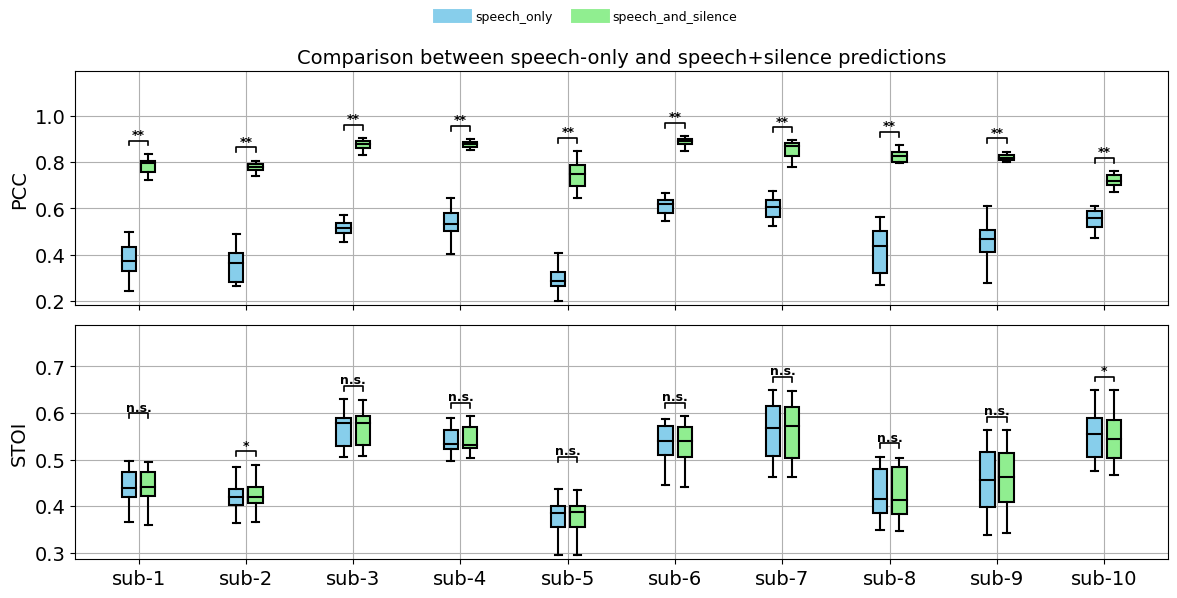

In [17]:
# ------------------------
# Load result files
# ------------------------
files = {
    "speech_only": "/home/ahmed348/TCNN_repo/pkl_files/TCNN_HGA_LFC_135_dil_151515_ker_7500_T_6_speech_only.pkl",
    # "silence_only": "/home/ahmed348/TCNN_repo/pkl_files/TCNN_HGA_LFC_579_dil_151515_ker_7500_T_6_sil_only.pkl",
    "speech_and_silence": "/home/ahmed348/TCNN_repo/pkl_files/TCNN_HGA_LFC_135_dil_151515_ker_7500_T_6.pkl",
}
method_order = list(files.keys())

# ------------------------
# Create figure with 2 subplots (PCC and STOI)
# ------------------------
metrics = ["PCC", "STOI"]
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

for ax_idx, metric in enumerate(metrics):
    # Load data for this metric
    results = {}
    for method, fpath in files.items():
        with open(fpath, "rb") as f:
            data = pickle.load(f)
            results[method] = data[metric]  # list of n_subjects, each with 10 folds

    # ------------------------
    # Prepare boxplot data
    # ------------------------
    n_subjects = len(next(iter(results.values())))   # should be 10
    methods = list(results.keys())
    n_methods = len(methods)

    positions = []
    box_data = []
    labels = []
    width = 0.18  # spacing between methods

    for subj_idx in range(n_subjects):
        for m_idx, method in enumerate(methods):
            subj_data = results[method][subj_idx]  # list of folds for this subject
            box_data.append(subj_data)
            positions.append(subj_idx + 1 + (m_idx - (n_methods-1)/2)*width)
            labels.append(f"Subj {subj_idx+1}" if m_idx == n_methods//2 else "")

    # ------------------------
    # Plot boxplot
    # ------------------------
    ax = axes[ax_idx]
    bp = ax.boxplot(
        box_data,
        positions=positions,
        vert=True,
        widths=0.75*width,
        patch_artist=True,
        showfliers=False,
        medianprops={'color': 'black', 'linewidth': 1.5},
        whiskerprops={'linewidth': 1.5, 'color': 'black'},
        capprops={'linewidth': 1.5, 'color': 'black'},
        boxprops={'linewidth': 1.5},
    )

    # Assign colors
    for m_idx, color in enumerate(COLORS[:n_methods]):
        for patch_idx in range(m_idx, len(bp["boxes"]), n_methods):
            bp["boxes"][patch_idx].set_facecolor(color)

    # X-axis ticks at subject centers
    ax.set_xticks(range(1, n_subjects+1))
    ax.set_xticklabels([f"sub-{i+1}" for i in range(n_subjects)], rotation=0)
    ax.tick_params(axis="both", labelsize=TICK_FONTSIZE_X_and_Y)

    ax.set_ylabel(metric, fontsize=YLABEL_FONTSIZE)
    if ax_idx == 0:
        ax.set_title(f"Comparison between speech-only and speech+silence predictions", fontsize=TITLE_FONTSIZE)

    ax.grid(True)

    # Extend ylim for stars
    data_list = box_data
    all_data = np.concatenate(data_list)
    yrange = all_data.max() - all_data.min()
    ax.set_ylim(all_data.min() - yrange*0.025, all_data.max() + yrange*0.39)

    # Significance stars
    pairs = [("speech_only", "speech_and_silence")]
    m_bonf = len(pairs)
    base_offset = yrange * 0.05
    bracket_width = yrange * 0.03

    for s_idx in range(n_subjects):
        start_idx = s_idx * n_methods
        subj_positions = [positions[start_idx + m] for m in range(n_methods)]
        subj_data_arrays = [data_list[start_idx + m] for m in range(n_methods)]
        ymax = max(max(arr) for arr in subj_data_arrays)

        for level, (m1, m2) in enumerate(pairs):
            m1_idx = method_order.index(m1)
            m2_idx = method_order.index(m2)
            a, b = results[m1][s_idx], results[m2][s_idx]

            try:
                _, pval = wilcoxon(b, a, alternative='two-sided')
            except Exception:
                pval = 1.0
            p_adj = min(pval * m_bonf, 1.0)
            stars = p_to_star(p_adj)

            x1, x2 = subj_positions[m1_idx], subj_positions[m2_idx]
            y = ymax + base_offset + level * (base_offset + bracket_width)

            ax.plot([x1, x1, x2, x2],
                    [y, y+bracket_width, y+bracket_width, y],
                    lw=1.2, c='black')
            ax.text((x1+x2)/2, y+bracket_width*0.9, stars,
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.95])  # leave space at top for legend
fig.legend(
    handles=[plt.Line2D([], [], color=COLORS[i], linewidth=10, label=method) for i, method in enumerate(methods)],
    loc='upper center',
    ncol=len(methods),
    frameon=False,
    fontsize=9
)

plt.savefig(
    "/home/ahmed348/TCNN_repo/figures/effect_of_speech_only_pred.pdf",
    bbox_inches="tight",
    dpi=DPI,
)
plt.show()


### **receptive field calculator**

In [ ]:
k = 15
d = [1,3,4]
RF = np.ones(len(d)+1)
print(RF) 
for i in range(len(d)):
    RF[i+1] = RF[i] + d[i]*(k-1)

print(RF[1:]) 

### **Generate sEEG plot for schematic in Introduction**

(30030, 254)


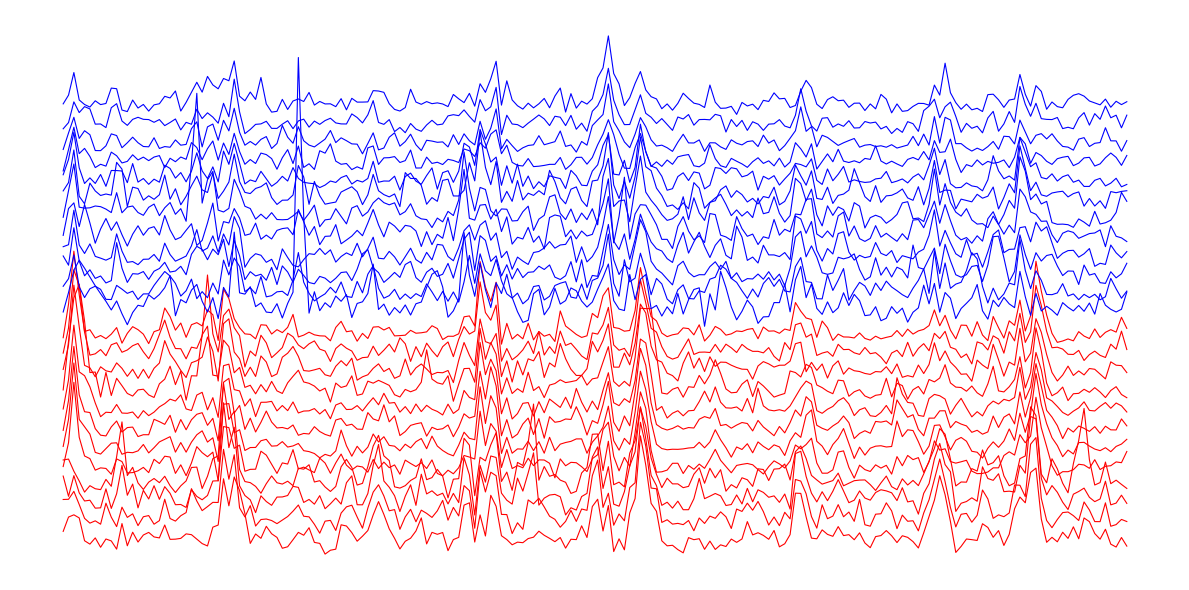

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_multichannel_timeseries(
    X,                  # shape: (T, C)
    max_channels=32,
    colors=("tab:blue", "tab:orange"),
    channel_spacing=None,
    linewidth=0.8
):
    T, C = X.shape
    C_plot = min(C, max_channels)
    X = X[:, :C_plot]

    if channel_spacing is None:
        channel_spacing = 1.2 * np.std(X)

    time = np.arange(T)
    split_idx = C_plot // 2

    plt.figure(figsize=(12, 6))

    for ch in range(C_plot):
        color = colors[0] if ch < split_idx else colors[1]
        plt.plot(
            time,
            X[:, ch] + ch * channel_spacing,
            color=color,
            linewidth=linewidth
        )

    plt.xlabel("Time")
    plt.ylabel("Channels (offset)")
    plt.yticks([])
    plt.box(False)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

# Fake data: (T, C)
T = 150
C = 24
feat = np.load('/scratch/gilbreth/ahmed348/Dutch_dataset_features/TCNN_folder/FEATURES/features_HGA_LFC/sub-01_feat.npy')
print(feat.shape)
# X = np.random.randn(T, C)
feat1 = feat[3100:3300, 90:90+25]

plot_multichannel_timeseries(
    feat1,
    max_channels=24,     # or 64
    colors=("red", "blue")
)

### **Generate log-mel spectrograms for schematic**

(30031, 80)


(-0.5, 599.5, 79.5, -0.5)

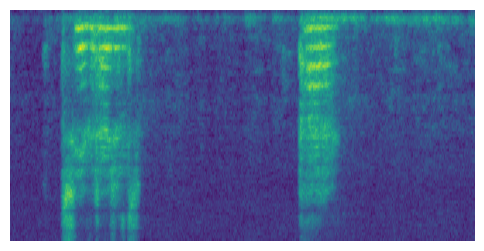

In [58]:
spectrogram = np.load('/scratch/gilbreth/ahmed348/Dutch_dataset_features/TCNN_folder/FEATURES/features_HGA_LFC/sub-01_spec.npy')
print(spectrogram.shape)
spec = spectrogram[1200:1800, :]

noise = np.random.randn(600, 80)
spec = spec + noise * 0.5
plt.figure(figsize=(6,3))
plt.imshow(spec.T, aspect='auto')
plt.axis('off')


### **Generate sample audio for schematic**

(14414532,)
audio time duration : 300.30275 sec
(288000,)


(-14399.95, 302398.95, -0.30169038420112554, 0.2860331763342965)

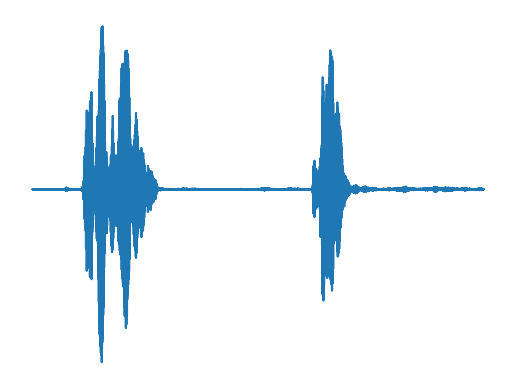

In [64]:
from pynwb import NWBHDF5IO

filepath = '/scratch/gilbreth/ahmed348/public_datasets/Dutch_Dataset/sub-01/ieeg/sub-01_task-wordProduction_ieeg.nwb'
io = NWBHDF5IO(filepath, 'r')
nwbfile = io.read()
audio = nwbfile.acquisition['Audio'].data[:]
print(audio.shape)
print(f'audio time duration : {len(audio)/48000} sec')
sr = 48000
audio_sample = audio[int(12*sr):int(18*sr)]
print(audio_sample.shape)
plt.plot(audio_sample)
plt.axis('off')